# SWC Prediction - Model Comparison and Feature Importance

## Necessary Imports

In [18]:
# System related imports
import os
import datetime
import IPython
import IPython.display

# General Imports
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# General ML Imports
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Tensorflow and Keras for CNN/LSTM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Dropout, LSTM

# Statsforecast, Statsmodels, and Utilsfo4recast for ARIMA/SARIMA
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, rmse, mape

# Suppress warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

## Helper Functions

Model Analysis Functions (for CNN/LSTM)

In [2]:
def plot_predictions(X_test, y_test, model, target_scaler, original_data, label_col="SWC_10"):
    # Predict and reshape
    y_preds = model.predict(X_test).reshape(-1, 1)
    y_actual = y_test.reshape(-1, 1)

    # Inverse transform
    y_preds_inv = target_scaler.inverse_transform(y_preds)
    y_actual_inv = target_scaler.inverse_transform(y_actual)

    # Match with correct timestamps from original data
    date_range = original_data.index[-len(y_preds_inv):]

    # Build results DataFrame
    results_df = pd.DataFrame({
        "date": date_range,
        "Actual SWC": y_actual_inv.flatten(),
        "Predicted SWC": y_preds_inv.flatten()
    })

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(results_df["date"], results_df["Actual SWC"], label="Actual SWC", color="blue")
    plt.plot(results_df["date"], results_df["Predicted SWC"], label="Predicted SWC", color="red", alpha=0.7)
    plt.title("SWC Forecast vs Actual (All Batches)")
    plt.xlabel("Time")
    plt.ylabel("SWC_10 (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [3]:
def report_metrics(X_test, y_test, model, scaler, label_col="SWC_10"):
    # Flatten predictions and labels
    y_pred = model.predict(X_test).flatten()
    y_true = y_test.flatten()

    # Inverse transform both
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()

    # Calculate metrics
    mse = mean_squared_error(y_true_inv, y_pred_inv)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    mape = mean_absolute_percentage_error(y_true_inv, y_pred_inv)
    corr = pearsonr(y_true_inv, y_pred_inv).statistic

    # Print results
    print(f"\n📊 Evaluation Metrics for {label_col}:")
    print(f"Mean Squared Error (MSE):      {mse:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Mean Absolute % Error (MAPE):  {mape * 100:.2f}%")
    print(f"Pearson Correlation (CORR):    {corr:.4f}")

Data Windowing Function

In [4]:
def data_to_X_y(data, window_size, offset):
    X, y = [], []
    for i in range(len(data) - window_size - offset):
        X.append(data[i:i+window_size, :])  
        y.append(data[i + window_size + offset, 0])  

    return  np.array(X),  np.array(y)

Feature Filtering Function

In [5]:
def filter_features(df, manual_features, label_col='y', threshold=0.95, auto_drop_high_corr=True):
    print("\n🔍 Starting feature filtering...")

    # Step 1: Identify all T_ and SWC_ columns to drop (unless manually kept)
    all_columns = df.columns.tolist()
    drop_t_cols = [col for col in all_columns if col.startswith('T_') and col not in manual_features]
    drop_swc_cols = [col for col in all_columns if col.startswith('SWC_') and col not in manual_features]

    df = df.drop(columns=drop_t_cols + drop_swc_cols, errors='ignore')

    # Step 2: Remove label column before correlation
    features_only = df.drop(columns=[label_col], errors='ignore')

    # Step 3: Separate manually selected features from the rest
    features_to_test = features_only.drop(columns=manual_features, errors='ignore')

    # Step 4: Optionally drop highly correlated features
    to_drop = []
    if auto_drop_high_corr:
        corr_matrix = features_to_test.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

    reduced_features = [col for col in features_to_test.columns if col not in to_drop]

    # Step 5: Final feature list
    final_features = manual_features + reduced_features

    # Step 6: Logging
    print(f"✅ Manually kept: {manual_features}")
    print(f"❌ Dropped other T_* columns: {drop_t_cols}")
    print(f"❌ Dropped other SWC_* columns: {drop_swc_cols}")
    if auto_drop_high_corr:
        print(f"❌ Auto-dropped due to high correlation (> {threshold}): {to_drop}")
    else:
        print("⚠️ Skipped auto-drop of correlated features")
    print(f"✅ Final kept features: {final_features}")

    return df[final_features]


In [6]:
def build_cnn_model(input_shape, params):
    model = Sequential([
        Conv1D(filters=params["filters"],
               kernel_size=params["kernel_size"],
               activation=params["activation"],
               padding='same',
               input_shape=input_shape),
        GlobalAveragePooling1D(),
        Dense(params["dense_units"], activation=params["activation"]),
        Dropout(params["dropout_rate"]),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])
    model.compile(loss='mae', optimizer=optimizer, metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

In [7]:
def build_lstm_model(input_shape, params):
    model = Sequential([
        LSTM(params["lstm_units"], activation=params["activation"], return_sequences=False, input_shape=input_shape),
        Dense(params["dense_units"], activation=params["activation"]),
        Dropout(params["dropout_rate"]),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])
    model.compile(loss='mae', optimizer=optimizer, metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

# Data Loading and Analysis

In [8]:
data = pd.read_csv('C:/Users/mnabh/Research - Soil Moisture Content/tx-soil-moisture/datasets/Revised_Final_Data/Station3_Revised_Final_Data.csv', 
    parse_dates=['Date'], index_col='Date')

Printing the head gives us a quick sample of how our data looks and what features we are working with.

In [9]:
print("\nHead:\n", data.head())


Head:
                       Ppt  SWC_5  SWC_10  SWC_20  SWC_50   T_5  T_10  T_20  \
Date                                                                         
2015-01-01 00:00:00  0.00  0.158   0.247   0.271   0.332  5.18  6.43  8.50   
2015-01-01 01:00:00  0.00  0.158   0.246   0.271   0.332  5.06  6.33  8.43   
2015-01-01 02:00:00  0.00  0.157   0.246   0.270   0.332  5.00  6.24  8.35   
2015-01-01 03:00:00  0.00  0.157   0.246   0.270   0.332  4.97  6.16  8.29   
2015-01-01 04:00:00  0.25  0.157   0.246   0.270   0.332  4.93  6.11  8.22   

                      T_50   Tair    RH  Windspeed  Winddirection  Srad  \
Date                                                                      
2015-01-01 00:00:00  12.78 -0.547  83.0      0.659          43.71  0.02   
2015-01-01 01:00:00  12.77 -0.440  81.6      0.670          67.43  0.20   
2015-01-01 02:00:00  12.73 -0.175  80.5      0.591          57.45  0.20   
2015-01-01 03:00:00  12.70 -0.047  80.8      0.727          77.78  0.1

Info shows us the data types we have and if we have to deal with any null values.

In [10]:
print("\nInfo:\n", data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52560 entries, 2015-01-01 00:00:00 to 2020-12-31 23:00:00
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ppt            52560 non-null  float64
 1   SWC_5          52560 non-null  float64
 2   SWC_10         52560 non-null  float64
 3   SWC_20         52560 non-null  float64
 4   SWC_50         52560 non-null  float64
 5   T_5            52560 non-null  float64
 6   T_10           52560 non-null  float64
 7   T_20           52560 non-null  float64
 8   T_50           52560 non-null  float64
 9   Tair           52560 non-null  float64
 10  RH             52560 non-null  float64
 11  Windspeed      52560 non-null  float64
 12  Winddirection  52560 non-null  float64
 13  Srad           52560 non-null  float64
 14  Latitude       52560 non-null  float64
 15  Longitude      52560 non-null  float64
dtypes: float64(16)
memory usage: 6.8 MB

Info:
 None


Describe allows us to look over some metrics for our features. 

Standard deviation and other distribution values give us an idea of how much the data conforms to a trend or pattern, which will reflect when we train models on it.

This can especially allow us to choose the right features to work with by picking the ones that have low std.

In [11]:
print("\nDescribe:\n", data.describe())


Describe:
                 Ppt         SWC_5        SWC_10        SWC_20        SWC_50  \
count  52560.000000  52560.000000  52560.000000  52560.000000  52560.000000   
mean       0.084603      0.166083      0.217468      0.257185      0.290596   
std        0.963606      0.047825      0.055837      0.064659      0.067676   
min        0.000000      0.077000      0.119000      0.143000      0.170000   
25%        0.000000      0.120000      0.164000      0.193000      0.223000   
50%        0.000000      0.166000      0.220000      0.277000      0.312000   
75%        0.000000      0.206000      0.265000      0.313000      0.351000   
max       62.740000      0.441000      0.444000      0.424000      0.454000   

                T_5          T_10          T_20          T_50          Tair  \
count  52560.000000  52560.000000  52560.000000  52560.000000  52560.000000   
mean      22.365382     22.381806     22.534643     22.690952     19.103507   
std        8.177372      7.836908      

A quick look at the distribution of SWC_10 values, the feature we want to trian on.

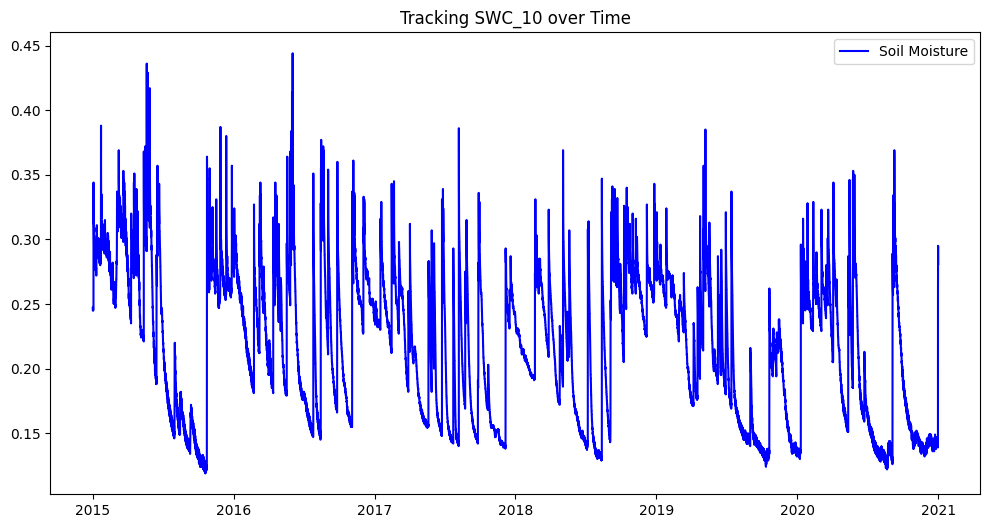

In [12]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['SWC_10'], label="Soil Moisture",color="blue")
plt.title("Tracking SWC_10 over Time")
plt.legend ()
plt.show()

A heatmap allow sus to see how well features correlate with each other, which reflects usefulness for including the features in a model.

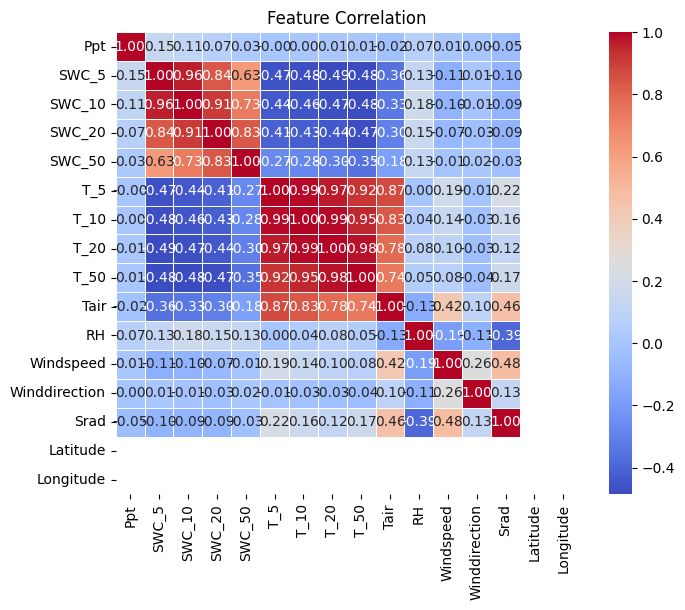

In [13]:
# Check Correlations
numeric_data = data.select_dtypes(include=["float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", square=True,
    linewidths=0.5, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Listing out the specific corr. values for our target feature

In [14]:
swc_corr = numeric_data.corr()['SWC_10'].sort_values(ascending=False)
print(swc_corr)

SWC_10           1.000000
SWC_5            0.962041
SWC_20           0.912022
SWC_50           0.728119
RH               0.180066
Ppt              0.110129
Winddirection   -0.013796
Srad            -0.091396
Windspeed       -0.095419
Tair            -0.332187
T_5             -0.441599
T_10            -0.455017
T_20            -0.468834
T_50            -0.480451
Latitude              NaN
Longitude             NaN
Name: SWC_10, dtype: float64


Fast Fourier Transform searches for seasonality in data, which helps us better find window/batch sizes and determine hyperparameters for seasonal models like SARIMA.

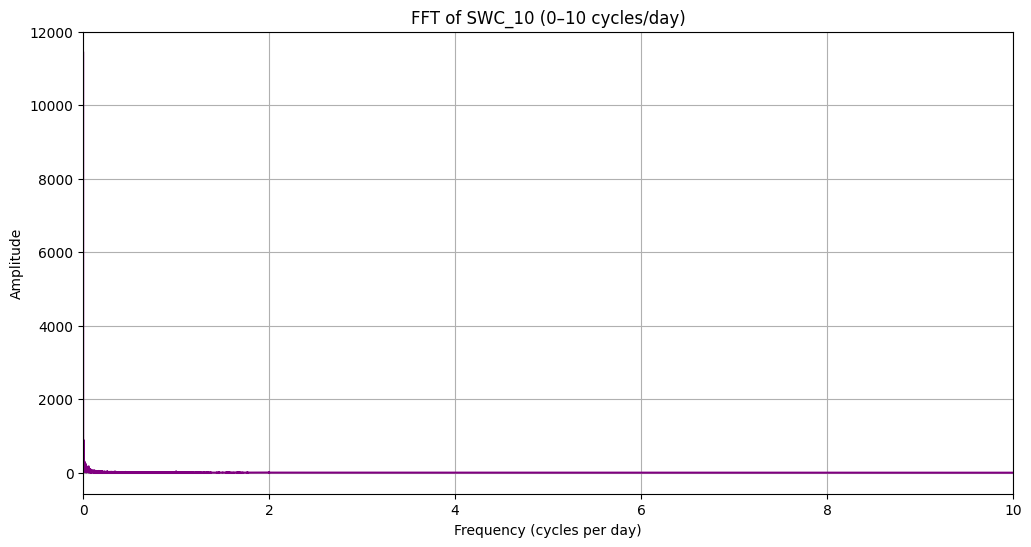

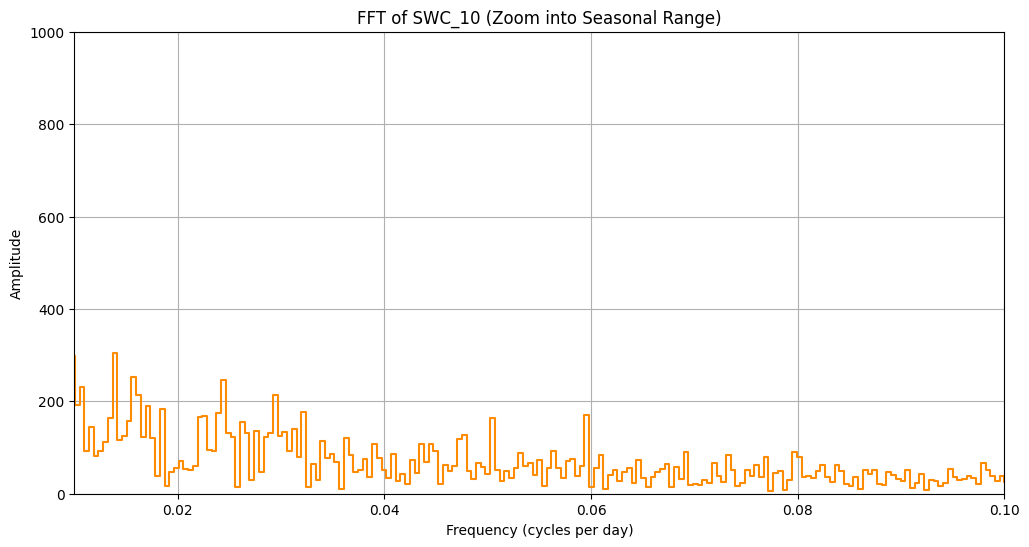

In [15]:
# Full FFT
swc = data['SWC_10'].values.astype(np.float32)
fft = tf.signal.rfft(swc)

samples_per_day = 24
n_samples = len(swc)
f_per_dataset = np.arange(0, len(fft))
f_per_day = f_per_dataset * (samples_per_day / n_samples)

# Plot: full spectrum up to 10 cycles/day
plt.figure(figsize=(12, 6))
plt.step(f_per_day, np.abs(fft), color='purple')
plt.xlabel('Frequency (cycles per day)')
plt.ylabel('Amplitude')
plt.title('FFT of SWC_10 (0–10 cycles/day)')
plt.xlim([0, 10])
plt.grid()
plt.show()

# Plot: zoom into low frequencies (seasonal/week/daily)
plt.figure(figsize=(12, 6))
plt.step(f_per_day, np.abs(fft), color='darkorange')
plt.xlabel('Frequency (cycles per day)')
plt.ylabel('Amplitude')
plt.title('FFT of SWC_10 (Zoom into Seasonal Range)')
plt.xlim([0.01, 0.1])     # Focus only where meaningful seasonal cycles might show
plt.ylim([0, 1000])        # Adjust this based on the spike's height; fine-tune interactively
plt.grid()
plt.show()



# Data Preparation

Feature Engineering

In [16]:
# Latitude and Longitude don't correlate with data trends.
# Perhaps in the future we can convert this into meaningful 
#   location data the model can understand.
# For now, we drop them and focus on other features.
data = data.drop(columns=['Latitude', 'Longitude'])

# Transform wind direction and speed into vector (Cartesian wind component)
data['Wind_X'] = data['Windspeed'] * np.cos(np.deg2rad(data['Winddirection']))
data['Wind_Y'] = data['Windspeed'] * np.sin(np.deg2rad(data['Winddirection']))
data = data.drop(columns=['Windspeed', 'Winddirection'])

# Create Time Features/ Transform date and time into more useful features
timestamp_s = data.index.map(pd.Timestamp.timestamp)
day = 24 * 60 * 60
year = (365.2425) * day

data['DaySin'] = np.sin(timestamp_s * (2 * np.pi / day))
data['DayCos'] = np.cos(timestamp_s * (2 * np.pi / day))
data['YearSin'] = np.sin(timestamp_s * (2 * np.pi / year))
data['YearCos'] = np.cos(timestamp_s * (2 * np.pi / year))

In [17]:
input_window = 72     # 3 days * 24 hours - Based on requirements
output_horizon = 48   # 2 days * 24 hours - Based on requirements

train_df = data[:'2018-12-31']
test_df = data['2019-01-01':'2019-12-31']

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[['SWC_10']])
test_scaled = scaler.transform(test_df[['SWC_10']])

target_scaler = StandardScaler()
manual_keep = ['SWC_10', 'T_5']
target_col = 'SWC_10'
train_df_lim = filter_features(train_df, manual_keep, label_col=target_col)
train_scaled_lim = target_scaler.fit_transform(train_df_lim[['SWC_10']])
test_df_lim = filter_features(test_df, manual_keep, label_col=target_col)
test_scaled_lim = target_scaler.transform(test_df_lim[['SWC_10']])

X_train, y_train = data_to_X_y(train_scaled, window_size=input_window, offset=0)
X_test, y_test = data_to_X_y(test_scaled, window_size=input_window, offset=0)

X_train_lim, y_train_lim = data_to_X_y(train_scaled_lim, window_size=input_window, offset=0)
X_test_lim, y_test_lim = data_to_X_y(test_scaled_lim, window_size=input_window, offset=0)


🔍 Starting feature filtering...
✅ Manually kept: ['SWC_10', 'T_5']
❌ Dropped other T_* columns: ['T_10', 'T_20', 'T_50']
❌ Dropped other SWC_* columns: ['SWC_5', 'SWC_20', 'SWC_50']
❌ Auto-dropped due to high correlation (> 0.95): []
✅ Final kept features: ['SWC_10', 'T_5', 'Ppt', 'Tair', 'RH', 'Srad', 'Wind_X', 'Wind_Y', 'DaySin', 'DayCos', 'YearSin', 'YearCos']

🔍 Starting feature filtering...
✅ Manually kept: ['SWC_10', 'T_5']
❌ Dropped other T_* columns: ['T_10', 'T_20', 'T_50']
❌ Dropped other SWC_* columns: ['SWC_5', 'SWC_20', 'SWC_50']
❌ Auto-dropped due to high correlation (> 0.95): []
✅ Final kept features: ['SWC_10', 'T_5', 'Ppt', 'Tair', 'RH', 'Srad', 'Wind_X', 'Wind_Y', 'DaySin', 'DayCos', 'YearSin', 'YearCos']


# Base CNN Model

In [41]:
# Define CNN model
cnn_model = Sequential([
    # Applies 64 filters (feature detectors), each looking at 3 time steps
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2])),
    # Pools across all time steps, summarizing each feature map into a single value
    GlobalAveragePooling1D(),
    # Dense layer for non-linear learning
    Dense(32, activation='relu'),
    # Dropout for regularization
    Dropout(0.2),
    # Final output layer (1 unit for SWC_10 prediction)
    Dense(1)
])

# Compile the model
cnn_model.compile(
    loss='mae',
    optimizer='adam',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
cnn_model.fit(X_train, y_train, epochs=40)


Epoch 1/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.2742 - root_mean_squared_error: 0.4321
Epoch 2/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.2120 - root_mean_squared_error: 0.3465
Epoch 3/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2063 - root_mean_squared_error: 0.3314
Epoch 4/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2032 - root_mean_squared_error: 0.3219
Epoch 5/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2016 - root_mean_squared_error: 0.3242
Epoch 6/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1929 - root_mean_squared_error: 0.3001
Epoch 7/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1804 - root_mean_squared_error: 0.2748
Epoch 8/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1753 - root_mean_squared_error: 0.2654
Epoch 9/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1667 - root_mean_squared_error: 0.2580
Epoch 10/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1561 - 

272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


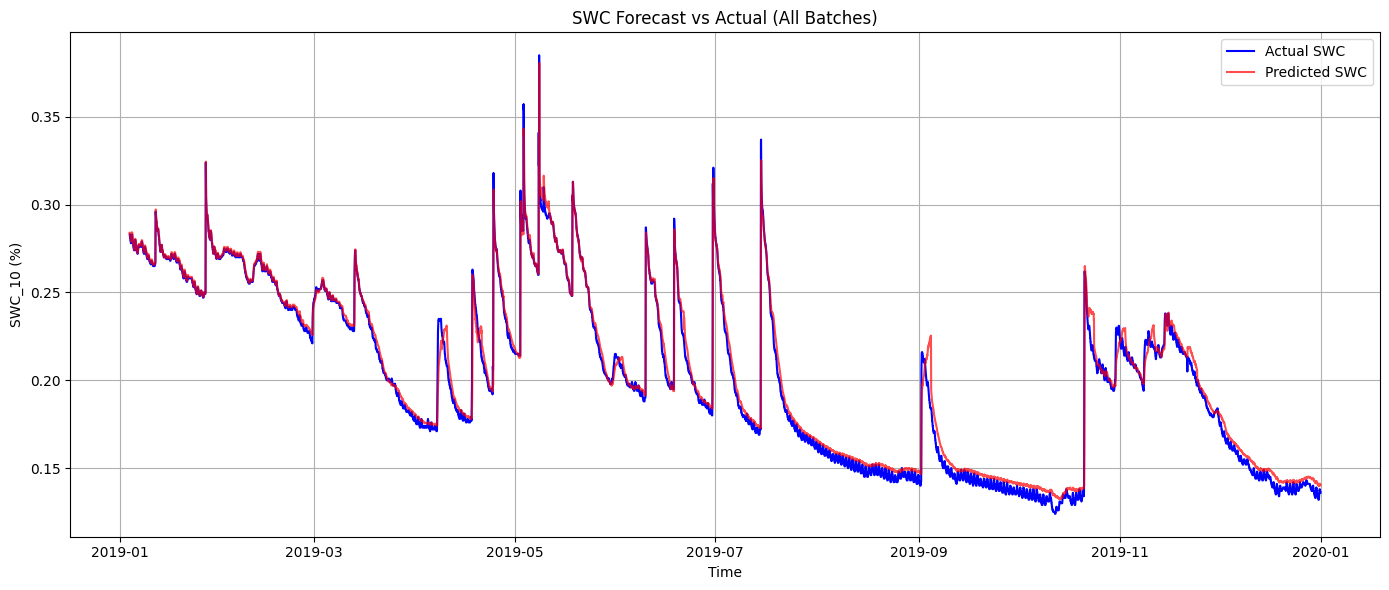

272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 Evaluation Metrics for SWC_10:
Mean Squared Error (MSE):      0.0000
Mean Absolute Error (MAE):     0.0038
Mean Absolute % Error (MAPE):  2.07%
Pearson Correlation (CORR):    0.9943


In [43]:
plot_predictions(X_test, y_test, cnn_model, scaler, test_df)

report_metrics(X_test, y_test, cnn_model, scaler)

# Tuning CNN Model Parameters

In [47]:
from itertools import product

cnn_param_grid = {
    "filters": [32, 64],
    "kernel_size": [3, 5],
    "dense_units": [16, 32],
    "dropout_rate": [0.0, 0.2],
    "learning_rate": [1e-3, 1e-4],
    "activation": ['relu', 'tanh']
}

keys, values = zip(*cnn_param_grid.items())
cnn_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

In [46]:
results = []
input_shape = (X_train.shape[1], X_train.shape[2])

for i, params in enumerate(cnn_param_combinations):
    print(f"{i+1}/{len(cnn_param_combinations)} | {params}")
    model = build_cnn_model(input_shape, params)
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=20, batch_size=32, verbose=0)
    score = model.evaluate(X_test, y_test, verbose=0)
    results.append({"params": params, "mae": score[0], "rmse": score[1]})

# Sort by MAE
best_result = sorted(results, key=lambda r: r["mae"])[0]
best_params = best_result["params"]


1/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.0, 'learning_rate': 0.001, 'activation': 'relu'}


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.0, 'learning_rate': 0.001, 'activation': 'tanh'}
3/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'activation': 'relu'}
4/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'activation': 'tanh'}
5/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'activation': 'relu'}
6/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'activation': 'tanh'}
7/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'activation': 'relu'}
8/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'activation': 'tanh'}
9/64 | {'filters': 32, 'kernel_size': 3, 'dense_units': 32, 'dropout_rate': 0.0, 'learning_rate': 0.001, 'a

Best CNN Based on Grid Search

In [ ]:

input_shape = (X_train_lim.shape[1], X_train_lim.shape[2])

best_cnn = build_cnn_model(input_shape, best_params)
best_cnn.compile(
    loss='mae',
    optimizer='adam',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

best_cnn.fit(X_train_lim, y_train_lim, epochs=40)


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.2198 - root_mean_squared_error: 0.4078
Epoch 2/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1421 - root_mean_squared_error: 0.2761
Epoch 3/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.1272 - root_mean_squared_error: 0.2508
Epoch 4/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0927 - root_mean_squared_error: 0.1982
Epoch 5/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0713 - root_mean_squared_error: 0.1632
Epoch 6/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0672 - root_mean_squared_error: 0.1602
Epoch 7/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0621 - root_mean_squared_error: 0.1493
Epoch 8/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0598 - root_mean_squared_error: 0.1577
Epoch 9/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0552 - root_mean_squared_error: 0.1314
Epoch 10/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0560 - 

272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


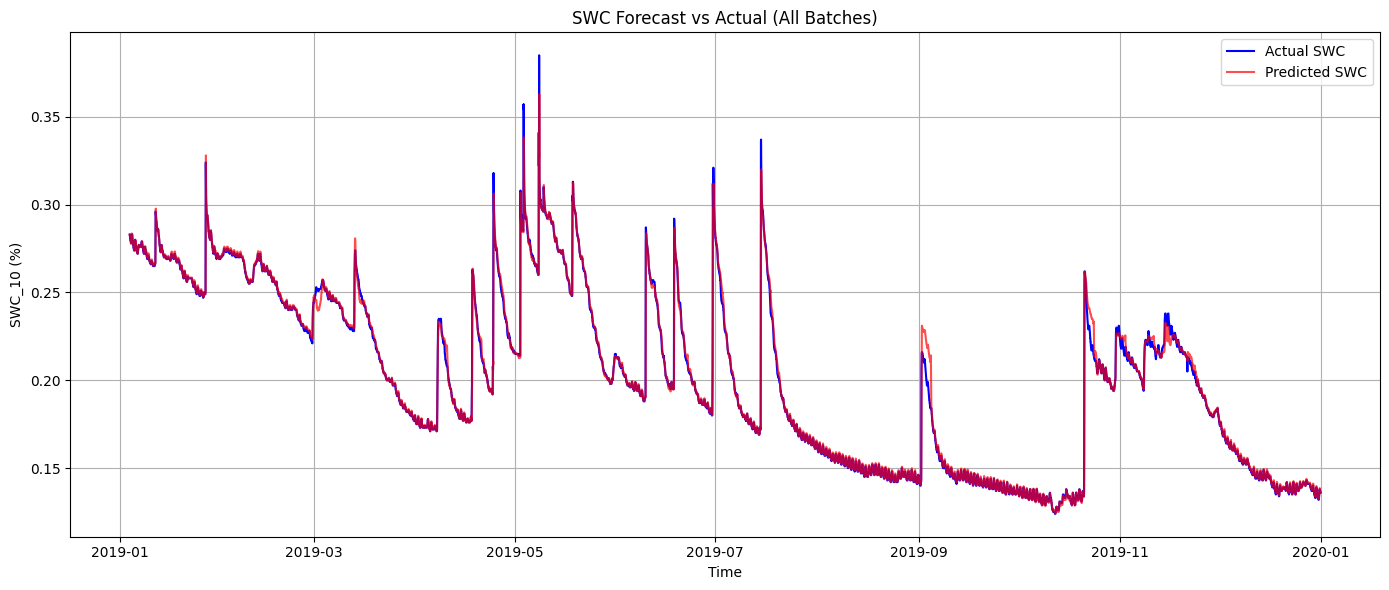

272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Evaluation Metrics for SWC_10:
Mean Squared Error (MSE):      0.0000
Mean Absolute Error (MAE):     0.0015
Mean Absolute % Error (MAPE):  0.70%
Pearson Correlation (CORR):    0.9962


In [111]:
plot_predictions(
    X_test=X_test_lim,
    y_test=y_test_lim,
    model=best_cnn,
    target_scaler=target_scaler,
    original_data=test_df_lim
)

report_metrics(X_test, y_test, best_cnn, target_scaler)

# Base LSTM Model

In [49]:
# Define LSTM model
lstm_model = Sequential([
    # LSTM with 64 memory cells, returning only the last output
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    # Dense layer for non-linear learning
    Dense(32, activation='relu'),
    # Dropout for regularization
    Dropout(0.2),
    # Final output layer (1 unit for SWC_10 prediction)
    Dense(1)
])

# Compile the model
lstm_model.compile(
    loss='mae',
    optimizer='adam',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
lstm_model.fit(X_train, y_train, epochs=40)

Epoch 1/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - loss: 0.1607 - root_mean_squared_error: 0.2742
Epoch 2/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - loss: 0.0999 - root_mean_squared_error: 0.1690
Epoch 3/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - loss: 0.0970 - root_mean_squared_error: 0.1575
Epoch 4/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.0967 - root_mean_squared_error: 0.1517
Epoch 5/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.0934 - root_mean_squared_error: 0.1518
Epoch 6/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - loss: 0.0957 - root_mean_squared_error: 0.1555
Epoch 7/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.0950 - root_mean_squared_error: 0.1521
Epoch 8/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - loss: 0.0948 - root_mean_squared_error: 0.1530
Epoch 9/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.0914 - root_mean_squared_error: 0.1452
Epoch 10/40
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/ste

272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


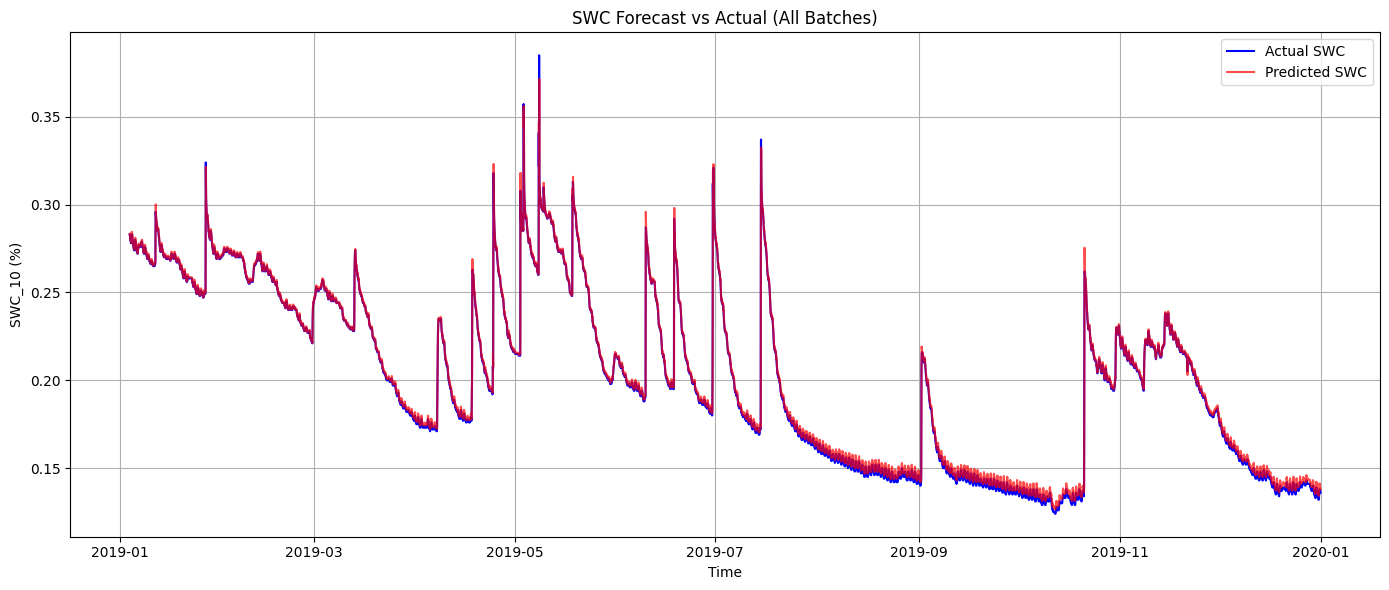

272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

📊 Evaluation Metrics for SWC_10:
Mean Squared Error (MSE):      0.0000
Mean Absolute Error (MAE):     0.0015
Mean Absolute % Error (MAPE):  0.87%
Pearson Correlation (CORR):    0.9983


In [51]:
plot_predictions(X_test, y_test, lstm_model, scaler, test_df)

report_metrics(X_test, y_test, lstm_model, scaler)

# Tuning LSTM Model Parameters

In [114]:
lstm_param_grid = {
    "lstm_units": [32, 64],
    "dense_units": [16, 32],
    "dropout_rate": [0.0, 0.2],
    "learning_rate": [1e-3, 1e-4],
    "activation": ['relu', 'tanh']
}

keys, values = zip(*lstm_param_grid.items())
lstm_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

In [115]:
# NEED TO  - Maybe overnight, takes time

results_lstm = []
input_shape = (X_train_lim.shape[1], X_train_lim.shape[2])

for i, params in enumerate(lstm_param_combinations):
    print(f"{i+1}/{len(lstm_param_combinations)} | {params}")
    model = build_lstm_model(input_shape, params)
    history = model.fit(X_train_lim, y_train_lim, validation_data=(X_test_lim, y_test_lim),
                        epochs=20, batch_size=32, verbose=0)
    score = model.evaluate(X_test_lim, y_test_lim, verbose=0)
    results_lstm.append({"params": params, "mae": score[0], "rmse": score[1]})

best_result_lstm = sorted(results_lstm, key=lambda r: r["mae"])[0]
best_lstm_params = best_result_lstm["params"]


1/32 | {'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.0, 'learning_rate': 0.001, 'activation': 'relu'}


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/32 | {'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.0, 'learning_rate': 0.001, 'activation': 'tanh'}
3/32 | {'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'activation': 'relu'}


KeyboardInterrupt: 

In [ ]:
best_lstm = build_lstm_model(input_shape, best_lstm_params)
best_lstm.fit(X_train_lim, y_train_lim, epochs=40)

plot_predictions(X_test_lim, y_test_lim, best_lstm, target_scaler, test_df_lim)
report_metrics(X_test_lim, y_test_lim, best_lstm, target_scaler)

# ARIMA/SARIMA

In [22]:
# Step 1: Prepare data in required format
df_swc = data[['SWC_10']].copy()
df_swc = df_swc.reset_index().rename(columns={'Date': 'ds', 'SWC_10': 'y'})
df_swc['unique_id'] = 'swc'
df_swc = df_swc[['unique_id', 'ds', 'y']]

# Step 2: Ensure 'ds' is datetime
df_swc['ds'] = pd.to_datetime(df_swc['ds'])

# Step 3: Apply same splitting logic using date ranges
train_df = df_swc[df_swc['ds'] <= '2018-12-31']
test_df = df_swc[(df_swc['ds'] >= '2019-01-01') & (df_swc['ds'] <= '2019-12-31')]

forecast_horizon = 48

In [53]:
sf_arima = StatsForecast(
    models=[AutoARIMA(max_p = 72, alias="ARIMA", seasonal=False)],
    freq="H",
    n_jobs=1
)

sf_arima.fit(train_df)

StatsForecast(models=[ARIMA])

C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\utilsforecast\processing.py:384: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\utilsforecast\processing.py:440: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


  unique_id metric     ARIMA
0       swc    mse  0.000007
1       swc    mae  0.002127
2       swc   mape  0.007774
  unique_id                  ds     ARIMA
0       swc 2018-12-31 01:00:00  0.271022
1       swc 2018-12-31 02:00:00  0.271045
2       swc 2018-12-31 03:00:00  0.271066
3       swc 2018-12-31 04:00:00  0.271084
4       swc 2018-12-31 05:00:00  0.271100
5       swc 2018-12-31 06:00:00  0.271115
6       swc 2018-12-31 07:00:00  0.271128
7       swc 2018-12-31 08:00:00  0.271140
8       swc 2018-12-31 09:00:00  0.271151
9       swc 2018-12-31 10:00:00  0.271161


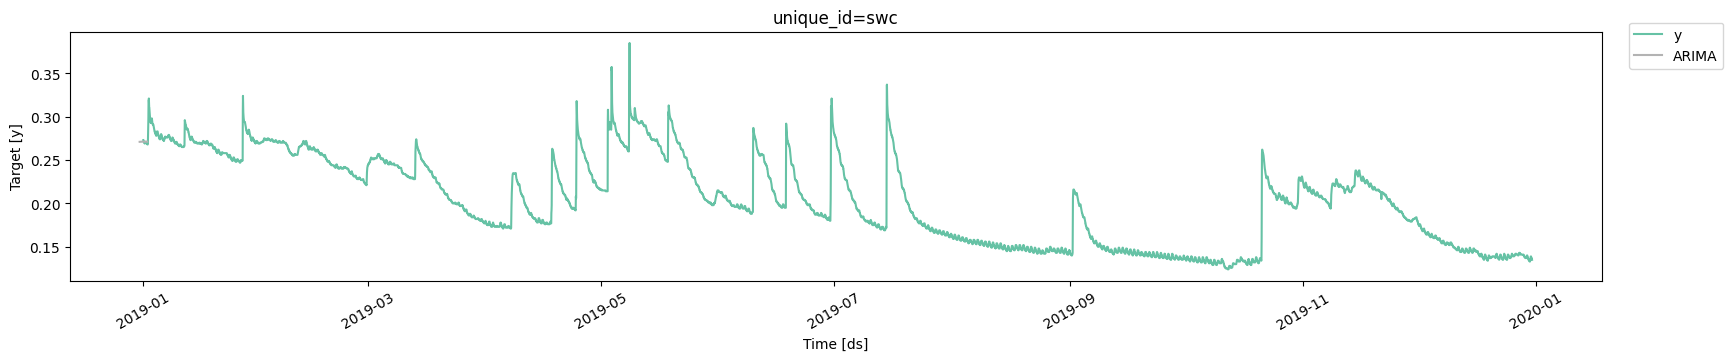

In [54]:
arima_forecast = sf_arima.predict(h=forecast_horizon)

merged_df = df_swc.merge(arima_forecast, on=["unique_id", "ds"])
metrics_df = evaluate(
    df=merged_df,
    metrics=[mse, mae, mape],
    models=["ARIMA"]
)
print(metrics_df)

print(arima_forecast.head(10))

plot_series(
    df=test_df, 
    forecasts_df=arima_forecast, 
    ids=['swc'],
    models=['ARIMA'],
    palette='Set2'
)


In [55]:
sf_sarima = StatsForecast(
    models=[AutoARIMA(max_p = 72, alias='SARIMA', seasonal=True, season_length=24)],
    freq='H',
    n_jobs=1
)

sf_sarima.fit(train_df)

StatsForecast(models=[SARIMA])

C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\utilsforecast\processing.py:384: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\utilsforecast\processing.py:440: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


  unique_id metric    SARIMA
0       swc    mse  0.006917
1       swc    mae  0.069542
2       swc   mape  0.419881
  unique_id                  ds  SARIMA
0       swc 2018-12-31 01:00:00   0.271
1       swc 2018-12-31 02:00:00   0.271
2       swc 2018-12-31 03:00:00   0.271
3       swc 2018-12-31 04:00:00   0.271
4       swc 2018-12-31 05:00:00   0.271
5       swc 2018-12-31 06:00:00   0.271
6       swc 2018-12-31 07:00:00   0.271
7       swc 2018-12-31 08:00:00   0.271
8       swc 2018-12-31 09:00:00   0.271
9       swc 2018-12-31 10:00:00   0.271


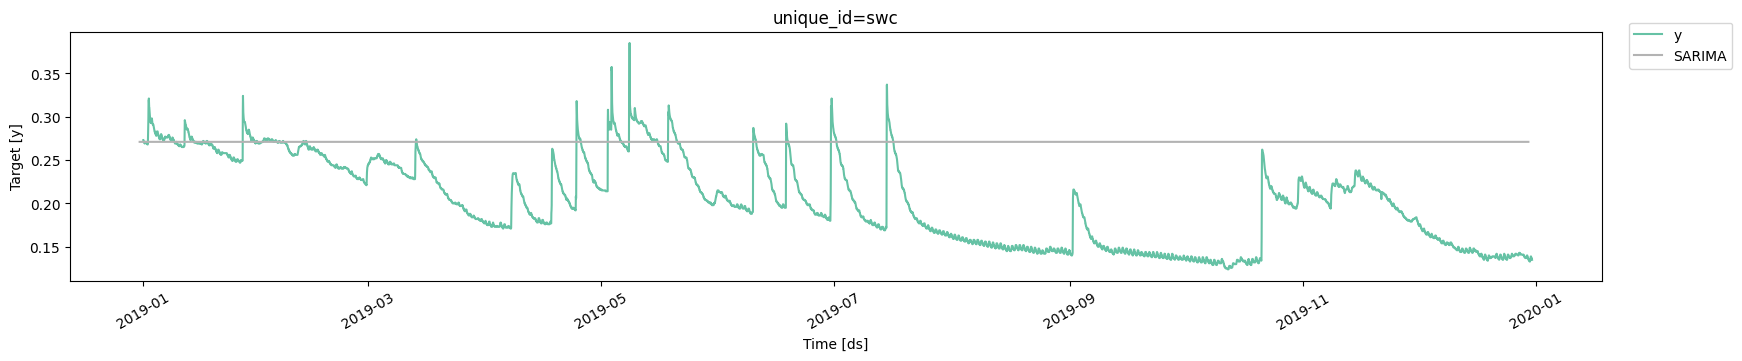

In [56]:
sarima_forecast = sf_sarima.predict(len(test_df))

merged_df = df_swc.merge(sarima_forecast, on=["unique_id", "ds"])
metrics_df = evaluate(
    df=merged_df,
    metrics=[mse, mae, mape],
    models=["SARIMA"]
)
print(metrics_df)

print(sarima_forecast.head(10))

plot_series(
    df=test_df,
    forecasts_df=sarima_forecast,
    ids=['swc'],
    models=['SARIMA'],     # Make sure this matches your model alias
    engine='matplotlib',
    palette='Set2'
)


C:\Users\mnabh\AppData\Local\Temp\ipykernel_3172\2641199531.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  train_resampled = train_df.select_dtypes(include=[np.number]).resample('6H').mean()
C:\Users\mnabh\AppData\Local\Temp\ipykernel_3172\2641199531.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  test_resampled = test_df.select_dtypes(include=[np.number]).resample('6H').mean()
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal AR

  unique_id metric  Predicted
0       swc    mae   0.023045
1       swc    mse   0.000531
2       swc   mape   0.113129


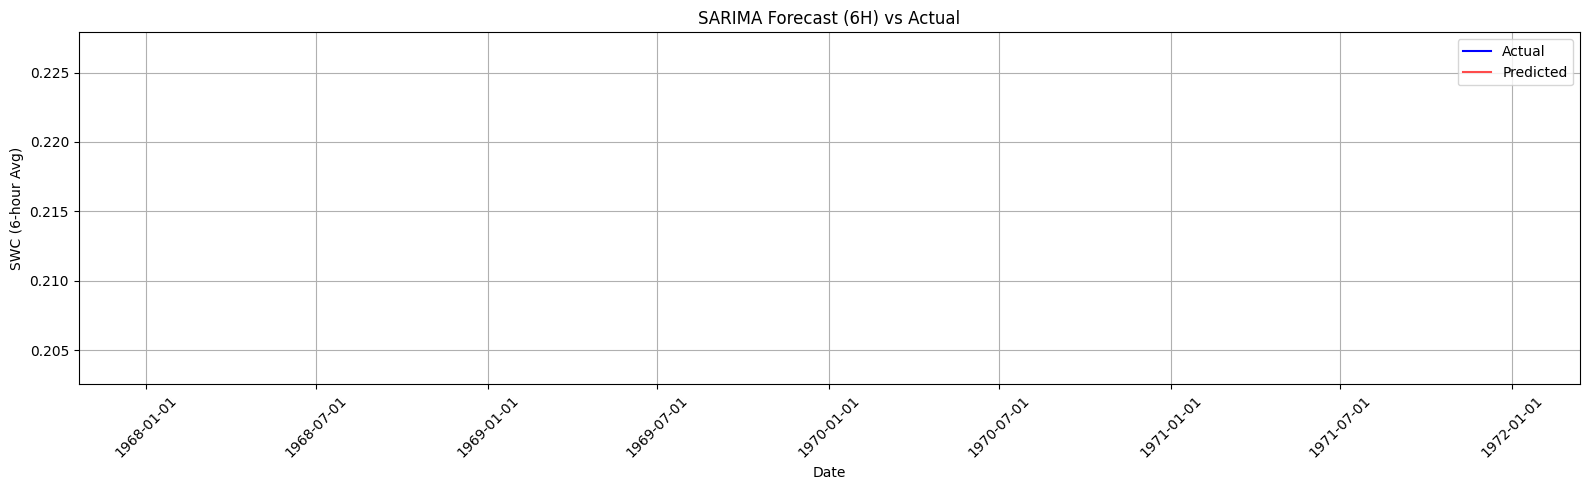

In [57]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, mape
import matplotlib.dates as mdates

# Step 1: Ensure datetime index
train_df.index = pd.to_datetime(train_df.index)
test_df.index = pd.to_datetime(test_df.index)

# Step 2: Light resampling every 6 hours
train_resampled = train_df.select_dtypes(include=[np.number]).resample('6H').mean()
test_resampled = test_df.select_dtypes(include=[np.number]).resample('6H').mean()

y_train = train_resampled["y"]
y_test = test_resampled["y"]

# Step 3: SARIMA model
sarima = SARIMAX(
    y_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 1460),  # yearly for 6-hour resolution
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)

# Step 4: Forecast
pred = sarima_fit.forecast(steps=len(y_test))

# Step 5: Build forecast DataFrame
forecast_df = pd.DataFrame({
    "unique_id": "swc",
    "ds": y_test.index,
    "y": y_test.values,
    "Predicted": pred.values
})

# Step 6: Evaluation
metrics_df = evaluate(forecast_df, metrics=[mae, mse, mape], models=["Predicted"])
print(metrics_df)

# Step 7: Custom plot zoomed to last 200 points
plot_df = forecast_df.tail(200)

plt.figure(figsize=(16, 5))
plt.plot(plot_df["ds"], plot_df["y"], label="Actual", color="blue")
plt.plot(plot_df["ds"], plot_df["Predicted"], label="Predicted", color="red", alpha=0.7)
plt.title("SARIMA Forecast (6H) vs Actual")
plt.xlabel("Date")
plt.ylabel("SWC (6-hour Avg)")
plt.legend()
plt.grid(True)

# Clean x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# ARIMAX

In [26]:
from itertools import combinations

def generate_feature_combinations(features):
    all_combos = []
    for r in range(1, len(features)+1):
        all_combos.extend(combinations(features, r))
    return all_combos

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

def try_arimax_combinations(y_train, y_test, train_df, test_df, exog_candidates, order=(2,1,2)):
    results = []

    for i, combo in enumerate(generate_feature_combinations(exog_candidates)):
        print(f"Trying combo {i+1}: {combo}")

        X_train = train_df[list(combo)]
        X_test = test_df[list(combo)]

        try:
            model = SARIMAX(y_train, exog=X_train, order=order, enforce_stationarity=False, enforce_invertibility=False)
            fit = model.fit(disp=False)
            preds = fit.forecast(steps=len(y_test), exog=X_test)

            df = pd.DataFrame({
                "unique_id": "swc",
                "ds": y_test.index,
                "y": y_test.values,
                "ARIMAX": preds.values
            })

            metrics = evaluate(df, metrics=[mae], models=["ARIMAX"])
            mae_score = metrics[metrics["metric"] == "mae"]["ARIMAX"].values[0]

            results.append({
                "features": combo,
                "mae": mae_score
            })

        except Exception as e:
            print(f"⚠️ Failed on combo {combo}: {e}")

    return sorted(results, key=lambda x: x["mae"])


In [28]:
exog_pool = ['T_5', 'Ppt', 'Tair', 'RH', 'Srad']
y_train = train_df_lim['SWC_10']
y_test = test_df_lim['SWC_10']

results = try_arimax_combinations(
    y_train=y_train,
    y_test=y_test,
    train_df=train_df_lim,
    test_df=test_df_lim,
    exog_candidates=exog_pool,
    order=(2, 1, 2)
)

# View best result
print("Best combo:", results[0])


Trying combo 1: ('T_5',)


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning

Trying combo 2: ('Ppt',)


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency inf

Trying combo 3: ('Tair',)


...

Trying combo 30: ('Ppt', 'Tair', 'RH', 'Srad')


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Trying combo 31: ('T_5', 'Ppt', 'Tair', 'RH', 'Srad')


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning

Best combo: {'features': ('T_5', 'Ppt', 'Tair', 'RH'), 'mae': 0.06492881617886571}


In [40]:
best_combo = results[0]["features"]
X_train_best = train_df_lim[list(best_combo)]
X_test_best = test_df_lim[list(best_combo)]

final_arimax = SARIMAX(
    y_train,
    exog=X_train_best,
    order=(4, 1, 3),  # You can tweak this
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_arimax.fit(disp=False)

C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [41]:
preds = final_fit.forecast(steps=len(y_test), exog=X_test_best)

final_forecast_df = pd.DataFrame({
    "unique_id": "swc",
    "ds": y_test.index,
    "y": y_test.values,
    "ARIMAX_best": preds.values
})

# Evaluate
metrics_final = evaluate(final_forecast_df, metrics=[mae, mse, mape], models=["ARIMAX_best"])
print(metrics_final)

# Plot
plot_series(
    df=final_forecast_df,  # keep 'y' column unchanged here
    forecasts_df=final_forecast_df.rename(columns={"ARIMAX_best": "Predicted"}),
    ids=["swc"],
    models=["Predicted"],
    engine="matplotlib",
    palette="Set2"
)


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


  unique_id metric  ARIMAX_best
0       swc    mae          NaN
1       swc    mse          NaN
2       swc   mape          NaN


C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\matplotlib\ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\matplotlib\ticker.py:2212: RuntimeWarning: overflow encountered in scalar multiply
  best_vmin = (_vmin // step) * step
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\matplotlib\ticker.py:2029: RuntimeWarning: invalid value encountered in scalar divmod
  d, m = divmod(x, self.step)
C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\matplotlib\ticker.py:2036: RuntimeWarning: invalid value encountered in scalar divmod
  d, m = divmod(x, self.step)


ValueError: arange: cannot compute length

<Figure size 1600x350 with 1 Axes>